 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # 1 Survival Prediction of the Titanic

 ## 1.1 Introduction

 This experiment predicts survival on Titanic based on passenger attributes.



 ### 1.2 Procedure

 #### 1.2.1 Importing Related Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

import seaborn as sns
sns.set_palette("husl")

import seaborn as sns
sns.set_palette("husl")
import seaborn as sns

%matplotlib inline


 #### 1.2.2 Importing Datasets



 **Step 1: Read data.**

 We will use the built-in Seaborn Titanic dataset to approximate `train.csv` and `test.csv`.

In [2]:
# Load standard titanic dataset 
titanic_full = sns.load_dataset('titanic')

# For the sake of matching the lab structure (train vs test splitting to mimic csv's)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(titanic_full, test_size=0.2, random_state=42)

# Simulating the test dataset without 'survived' target 
# Note: we keep the original test_target to evaluate at the end
test_target = test_df['survived']
test_df = test_df.drop('survived', axis=1)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (712, 15)
Test shape: (179, 14)


 **Step 2: View Data.**

In [3]:
print("\nFirst 5 rows of train:")
print(train_df.head())

print("\nLast 5 rows of train:")
print(train_df.tail())

print("\nData Info for Train data:")
train_df.info()

print("\nStatistical description of Train data:")
print(train_df.describe())

print("\nStatistical description of categorical columns:")
print(train_df.describe(include=['O', 'category']))



First 5 rows of train:
     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
331         0       1    male  45.5      0      0  28.5000        S   First   
733         0       2    male  23.0      0      0  13.0000        S  Second   
382         0       3    male  32.0      0      0   7.9250        S   Third   
704         0       3    male  26.0      1      0   7.8542        S   Third   
813         0       3  female   6.0      4      2  31.2750        S   Third   

       who  adult_male deck  embark_town alive  alone  
331    man        True    C  Southampton    no   True  
733    man        True  NaN  Southampton    no   True  
382    man        True  NaN  Southampton    no   True  
704    man        True  NaN  Southampton    no  False  
813  child       False  NaN  Southampton    no  False  

Last 5 rows of train:
     survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
106         1       3  female  21.0      0      0    7.6500    

/tmp/ipykernel_677966/1527312068.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train_df.describe(include=['O', 'category']))


 **Step 3: Check the survival probability corresponding to each feature based on statistics.**


Survival by Pclass:
   pclass  survived
0       1  0.607362
1       2  0.483444
2       3  0.241206

Survival by SibSp:
   sibsp  survived
0      0  0.345041
1      1  0.506098
2      2  0.478261
3      3  0.307692
4      4  0.187500
5      5  0.000000
6      8  0.000000

Survival by Sex:
      sex  survived
0  female  0.738776
1    male  0.186296


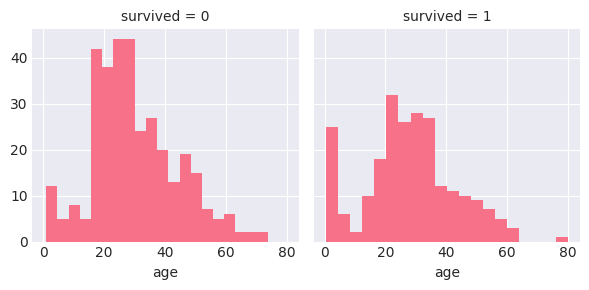

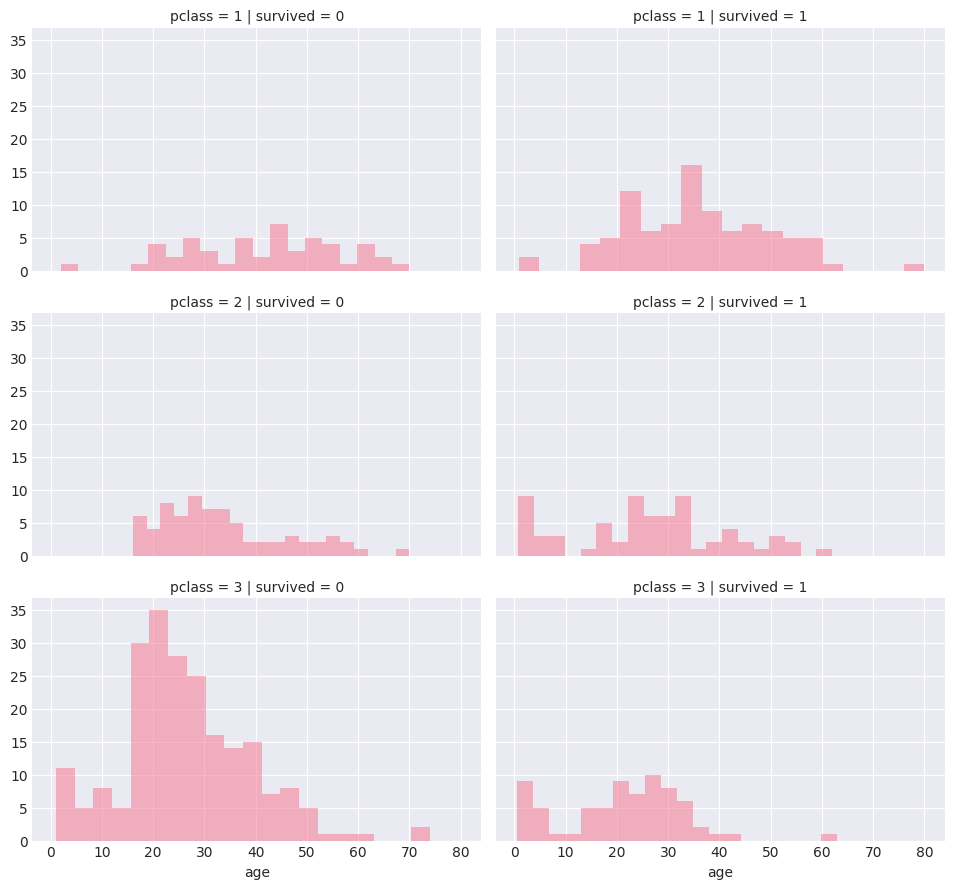

In [4]:
print("\nSurvival by Pclass:")
print(train_df[['pclass', 'survived']].groupby(['pclass'], as_index=False).mean())

print("\nSurvival by SibSp:")
print(train_df[['sibsp', 'survived']].groupby(['sibsp'], as_index=False).mean())

print("\nSurvival by Sex:")
print(train_df[['sex', 'survived']].groupby(['sex'], as_index=False).mean())

# Visualization
g = sns.FacetGrid(train_df, col='survived')
g.map(plt.hist, 'age', bins=20)
plt.show()

# Pclass vs Survived vs Age
grid = sns.FacetGrid(train_df, col='survived', row='pclass', aspect=1.6)
grid.map(plt.hist, 'age', alpha=.5, bins=20)
grid.add_legend()
plt.show()


 #### 1.2.3 Preprocessing Data



 **Step 1: Combine the datasets.**

In [5]:
# In order to process consistently, let's keep track of train and test split index
ntrain = train_df.shape[0]
ntest = test_df.shape[0]

# Add survived columns with NaNs to test_df to allow concat
test_df_copy = test_df.copy()
test_df_copy['survived'] = np.nan

all_data = pd.concat([train_df, test_df_copy], ignore_index=True)

print("Combined dataset shape:", all_data.shape)


Combined dataset shape: (891, 15)


 **Step 2: Check for missing values.**

In [6]:
print("\nMissing values in combined data:")
print(all_data.isnull().sum())



Missing values in combined data:
survived       179
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


 **Step 3: Fill the missing values with data.**

In [7]:
# Fill Age with mean
age_mean = all_data['age'].mean()
all_data['age'] = all_data['age'].fillna(age_mean)

# Fill Embarked and Fare with mode properly
if all_data['embarked'].isnull().sum() > 0:
    all_data['embarked'] = all_data['embarked'].fillna(all_data['embarked'].mode()[0])

if all_data['fare'].isnull().sum() > 0:
    all_data['fare'] = all_data['fare'].fillna(all_data['fare'].mode()[0])

# Delete less significant data
cols_to_drop = ['alive', 'deck', 'adult_male', 'who', 'alone', 'class', 'embark_town']
all_data.drop(columns=[c for c in cols_to_drop if c in all_data.columns], inplace=True)

print("\nMissing values after processing:")
print(all_data.isnull().sum())



Missing values after processing:
survived    179
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
dtype: int64


 **Step 4: Convert data.**

In [8]:
# Check number of types for 'sex'
print("\nValue counts for Sex:")
print(all_data['sex'].value_counts())

# Map 'sex' and 'embarked' to numeric using map technique
all_data['sex'] = all_data['sex'].map({'male': 0, 'female': 1})

# Example replacing embarked text mapping to int 
all_data['embarked'] = all_data['embarked'].map({'S': 0, 'C': 1, 'Q': 2})



Value counts for Sex:
sex
male      577
female    314
Name: count, dtype: int64


 #### 1.2.4 Building a Model



 **Step 1: Split the dataset.**

 Extract train and test back. Note test does not have truth labels inside all_data since we are pretending.

In [9]:
# Retrieve train and test sets
train = all_data[:ntrain]
test = all_data[ntrain:].drop('survived', axis=1)

X_train = train.drop('survived', axis=1)
y_train = train['survived']

# Fill any lingering nans (just in case due to pd.concat)
X_train = X_train.fillna(0)
test = test.fillna(0)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("test shape:", test.shape)



X_train shape: (712, 7)
y_train shape: (712,)
test shape: (179, 7)


 **Step 2: Train a model.**

 Using Logistic Regression, Random Forest, AdaBoost

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Because we simulated train test split, we can actually evaluate performance against test_target!
X_test = test 
y_test = test_target

# Logistic Regression
logR = LogisticRegression(max_iter=1000)
logR.fit(X_train, y_train)
acc_logR = logR.score(X_test, y_test)
print(f"LogR {acc_logR:.16f}")

# Random Forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
acc_rfc = rfc.score(X_test, y_test)
print(f"RFC {acc_rfc:.16f}")

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
acc_ada = ada.score(X_test, y_test)
print(f"AdaBoost {acc_ada:.16f}")


LogR 0.7988826815642458
RFC 0.8212290502793296


AdaBoost 0.7932960893854749


 **Step 3: Predict data.**

 Use the best model (RFC) to produce predictions.

In [11]:
predictions = rfc.predict(test)
print("\nFirst 20 Predictions (RFC):")
print(predictions[:20])



First 20 Predictions (RFC):
[0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
